# **03: Python Pandas and NumPy Analytics**

**Module:** Databases and Analytics (CP6UA56O)  
**Case study:** NorthStar Urban Mobility and Logistics

This notebook uses the cleaned NorthStar outputs from the data audit stage for deeper Python analytics. Pandas, NumPy, Matplotlib, and Seaborn are used to analyse operational relationships, create numerical summaries, and produce visual evidence for the coursework report.

---
## **Import Libraries**

Standard Python data science libraries are loaded first. The cleaned CSV files are imported directly from the GitHub repository into Google Colab.

In [1]:
import os
import warnings
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully.')


Libraries loaded successfully.


---
## **Set GitHub Data Source and Local Output Folder**

The cleaned files are imported directly from the GitHub repository. Output charts and summary tables are saved locally in the Colab session, then zipped for manual upload to the GitHub `Outputs/Python_Outputs` folder.

In [2]:
CLEANED_BASE_URL = 'https://raw.githubusercontent.com/SamsonSiby5827/Northstar_Databases_Analytics_Coursework/main/Data/Cleaned'
OUTPUT_PATH = Path('/content/northstar_python_outputs')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print('GitHub cleaned data source:')
print(CLEANED_BASE_URL)
print('\nPython output path:')
print(OUTPUT_PATH)


GitHub cleaned data source:
https://raw.githubusercontent.com/SamsonSiby5827/Northstar_Databases_Analytics_Coursework/main/Data/Cleaned

Python output path:
/content/northstar_python_outputs


---
## **Load All Cleaned Datasets from GitHub**

The main datasets are loaded from the GitHub `Data/Cleaned` folder. The merged operational dataset `ops_merged.csv` is the primary file for analysis because it combines orders, deliveries, customers, hubs, drivers, and vehicles into one view. The complaint, incident, and app event files are also loaded for specific analyses.

In [3]:
def github_csv(filename):
    return f'{CLEANED_BASE_URL}/{filename}'

# Load merged and summary files from GitHub
ops_df       = pd.read_csv(github_csv('ops_merged.csv'))
complaint_df = pd.read_csv(github_csv('complaints_merged.csv'))
incident_df  = pd.read_csv(github_csv('incidents_merged.csv'))
app_events   = pd.read_csv(github_csv('app_events_clean.csv'))
zone_perf    = pd.read_csv(github_csv('zone_performance_summary.csv'))
hub_perf     = pd.read_csv(github_csv('hub_performance_summary.csv'))

# Load individual cleaned files for additional checks and merge demonstration
orders      = pd.read_csv(github_csv('orders_clean.csv'))
deliveries  = pd.read_csv(github_csv('deliveries_clean.csv'))
complaints  = pd.read_csv(github_csv('complaints_clean.csv'))
incidents   = pd.read_csv(github_csv('incidents_clean.csv'))
customers   = pd.read_csv(github_csv('customers_clean.csv'))
drivers     = pd.read_csv(github_csv('drivers_clean.csv'))
vehicles    = pd.read_csv(github_csv('vehicles_clean.csv'))
hubs        = pd.read_csv(github_csv('hubs_clean.csv'))

# Quick summary of loaded datasets
loaded_summary = pd.DataFrame({
    'dataset': [
        'ops_df', 'complaint_df', 'incident_df', 'app_events',
        'zone_perf', 'hub_perf', 'orders', 'deliveries', 'complaints',
        'incidents', 'customers', 'drivers', 'vehicles', 'hubs'
    ],
    'rows': [
        len(ops_df), len(complaint_df), len(incident_df), len(app_events),
        len(zone_perf), len(hub_perf), len(orders), len(deliveries), len(complaints),
        len(incidents), len(customers), len(drivers), len(vehicles), len(hubs)
    ],
    'columns': [
        ops_df.shape[1], complaint_df.shape[1], incident_df.shape[1], app_events.shape[1],
        zone_perf.shape[1], hub_perf.shape[1], orders.shape[1], deliveries.shape[1],
        complaints.shape[1], incidents.shape[1], customers.shape[1], drivers.shape[1],
        vehicles.shape[1], hubs.shape[1]
    ]
})

print('Cleaned datasets loaded successfully from GitHub.')
loaded_summary


Cleaned datasets loaded successfully from GitHub.


,dataset,rows,columns
0,ops_df,1250,59
1,complaint_df,320,22
2,incident_df,280,20
3,app_events,640,12
4,zone_perf,7,11
5,hub_perf,8,10
6,orders,1250,16
7,deliveries,950,21
8,complaints,320,11
9,incidents,280,7


---
## **Prepare Date and Numeric Columns**

Date columns are converted to Pandas datetime objects. Important numeric columns are also confirmed as numeric types, because CSV loading can sometimes read them as strings. This step ensures all calculations are reliable.

In [4]:
# Convert date columns
# This prepares date fields for time based analysis later in the notebook.

date_map = [
    (ops_df, ['order_created_at', 'dispatch_time', 'delivery_completed_at']),
    (complaint_df, ['created_at', 'order_created_at']),
    (incident_df, ['reported_at']),
    (app_events, ['event_timestamp']),
    (orders, ['order_created_at']),
    (deliveries, ['dispatch_time', 'delivery_completed_at'])
]

for df, cols in date_map:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

# Convert important numeric columns
numeric_cols = [
    'completion_hours_clean',
    'cost_per_km',
    'customer_rating_post_delivery',
    'is_bad_outcome',
    'manual_route_override_count',
    'order_value',
    'route_distance_km',
    'fuel_or_charge_cost',
    'promised_window_hours'
]

for df in [ops_df, complaint_df, incident_df, app_events, orders, deliveries]:
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

print('Date and numeric preparation complete.')

print('\nKey column types in ops_df:')
key_cols_check = [
    'completion_hours_clean',
    'cost_per_km',
    'customer_rating_post_delivery',
    'is_bad_outcome',
    'manual_route_override_count',
    'order_value'
]

print(ops_df[[c for c in key_cols_check if c in ops_df.columns]].dtypes)

Date and numeric preparation complete.

Key column types in ops_df:
completion_hours_clean           float64
cost_per_km                      float64
customer_rating_post_delivery    float64
is_bad_outcome                   float64
manual_route_override_count      float64
order_value                      float64
dtype: object


---
## **Data Quality Check**

This step confirms the shape, duplicate count, and total missing values for the main analysis datasets. It is a quick check to confirm that data quality has been preserved from Notebook 1.

In [5]:
quality_summary = []
for name, df in {
    'ops_df': ops_df, 'complaint_df': complaint_df,
    'incident_df': incident_df, 'app_events': app_events
}.items():
    quality_summary.append({
        'dataset':         name,
        'rows':            df.shape[0],
        'columns':         df.shape[1],
        'duplicate_rows':  int(df.duplicated().sum()),
        'total_missing':   int(df.isna().sum().sum())
    })

pd.DataFrame(quality_summary)

,dataset,rows,columns,duplicate_rows,total_missing
0,ops_df,1250,59,0,11018
1,complaint_df,320,22,0,531
2,incident_df,280,20,0,17
3,app_events,640,12,0,144


---
## **Identify Numerical Columns**

The rubric specifically mentions identifying numerical features in the input dataframe. This step selects the numerical columns in `ops_df` and lists them explicitly. This forms the basis for all statistical calculations and pairwise plots that follow.

In [6]:
# Automatically select numerical columns from ops_df
all_numeric_cols = ops_df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Total numerical columns in ops_df: {len(all_numeric_cols)}')
print('\nAll numerical columns:')
print(all_numeric_cols)

# Select the subset most relevant for analysis
# (Exclude flag/binary columns and ID-derived columns from statistical summaries)
KEY_NUMERIC = [
    'route_distance_km',
    'manual_route_override_count',
    'fuel_or_charge_cost',
    'cost_per_km',
    'completion_hours_clean',
    'customer_rating_post_delivery',
    'order_value',
    'promised_window_hours'
]
KEY_NUMERIC = [c for c in KEY_NUMERIC if c in ops_df.columns]

print(f'\nKey numerical columns selected for analysis ({len(KEY_NUMERIC)} columns):')
print(KEY_NUMERIC)

Total numerical columns in ops_df: 29

All numerical columns:
['promised_window_hours', 'order_value', 'special_handling_flag', 'order_hour', 'has_complaint', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost', 'is_delayed', 'is_failed', 'is_bad_outcome', 'completion_hours', 'negative_completion_time_flag', 'completion_hours_clean', 'cost_per_km', 'has_incident', 'age', 'loyalty_score', 'app_engagement_score', 'capacity_score', 'years_experience', 'training_score', 'driver_rating', 'battery_health_pct', 'low_battery_flag', 'in_repair_flag', 'missed_promised_window']

Key numerical columns selected for analysis (8 columns):
['route_distance_km', 'manual_route_override_count', 'fuel_or_charge_cost', 'cost_per_km', 'completion_hours_clean', 'customer_rating_post_delivery', 'order_value', 'promised_window_hours']


---
## **Descriptive Statistics Using Pandas and NumPy**

This section calculates descriptive statistics for the key numerical columns. Pandas `.describe()` gives a full overview. NumPy functions then demonstrate explicit calculation of mean, median, standard deviation, minimum, maximum, and percentiles. This approach satisfies the rubric requirement to use both Pandas and NumPy for data analysis.

In [7]:
# Pandas descriptive statistics for all key numerical columns
print('=== Overall Descriptive Statistics (Pandas) ===')
overall_stats = (
    ops_df[KEY_NUMERIC]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T
    .rename(columns={'50%': 'median', '25%': 'q25', '75%': 'q75'})
    [['count', 'mean', 'std', 'min', 'q25', 'median', 'q75', 'max']]
    .round(2)
)
display(overall_stats)

=== Overall Descriptive Statistics (Pandas) ===


,count,mean,std,min,q25,median,q75,max
route_distance_km,950.000,13.910,7.480,1.200,9.140,12.840,16.840,41.940
manual_route_override_count,950.000,0.970,1.090,0.000,0.000,1.000,2.000,7.000
fuel_or_charge_cost,950.000,12.840,4.340,2.500,9.930,12.640,15.700,29.430
cost_per_km,950.000,1.260,1.240,0.170,0.700,0.950,1.330,12.360
completion_hours_clean,867.000,10.320,8.460,0.020,3.500,7.910,15.530,43.460
customer_rating_post_delivery,936.000,3.860,0.890,1.000,3.360,4.040,4.550,5.000
order_value,1250.000,91.050,60.920,2.040,47.920,76.530,121.100,510.060
promised_window_hours,1250.000,7.620,7.060,1.000,4.000,6.000,12.000,24.000


In [8]:
# NumPy explicit calculation for four key delivery variables
# This demonstrates direct use of NumPy statistical functions on the data
print('=== NumPy Explicit Statistical Calculations ===')

numpy_cols = ['completion_hours_clean', 'cost_per_km',
              'customer_rating_post_delivery', 'manual_route_override_count']
numpy_cols = [c for c in numpy_cols if c in ops_df.columns]

numpy_results = []
for col in numpy_cols:
    values = ops_df[col].dropna().to_numpy()
    numpy_results.append({
        'column':        col,
        'n':             len(values),
        'mean':          round(np.mean(values),        2),
        'median':        round(np.median(values),      2),
        'std':           round(np.std(values, ddof=1), 2),
        'min':           round(np.min(values),         2),
        'q25':           round(np.percentile(values, 25), 2),
        'q75':           round(np.percentile(values, 75), 2),
        'max':           round(np.max(values),         2),
    })

numpy_df = pd.DataFrame(numpy_results)
display(numpy_df)

print('\nInterpretation: The NumPy calculations confirm the Pandas results above. '
      'Using np.std with ddof=1 gives the sample standard deviation, which is the correct '
      'measure when working with a sample rather than the full population.')

=== NumPy Explicit Statistical Calculations ===


,column,n,mean,median,std,min,q25,q75,max
0,completion_hours_clean,867,10.320,7.910,8.460,0.020,3.500,15.530,43.460
1,cost_per_km,950,1.260,0.950,1.240,0.170,0.700,1.330,12.360
2,customer_rating_post_delivery,936,3.860,4.040,0.890,1.000,3.360,4.550,5.000
3,manual_route_override_count,950,0.970,1.000,1.090,0.000,0.000,2.000,7.000



Interpretation: The NumPy calculations confirm the Pandas results above. Using np.std with ddof=1 gives the sample standard deviation, which is the correct measure when working with a sample rather than the full population.


In [9]:
# Grouped statistics by delivery status using pd.NamedAgg for clean column naming
print('=== Descriptive Statistics Grouped by Delivery Status ===')

# Only use columns that are in the dataframe
group_cols = [c for c in KEY_NUMERIC if c in ops_df.columns]

group_stats_list = []
for col in group_cols:
    tmp = (
        ops_df.groupby('delivery_status')[col]
        .agg(
            count='count',
            mean='mean',
            median='median',
            std='std',
            min='min',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            max='max'
        )
        .round(2)
        .reset_index()
    )
    tmp.insert(0, 'column', col)
    group_stats_list.append(tmp)

grouped_stats = pd.concat(group_stats_list, ignore_index=True)
display(grouped_stats)

print('\nInterpretation: Comparing statistics across delivery statuses shows whether '
      'delayed and failed services have systematically higher costs, longer times, '
      'or lower ratings than on-time deliveries.')

=== Descriptive Statistics Grouped by Delivery Status ===


,column,delivery_status,count,mean,median,std,min,q25,q75,max
0,route_distance_km,Delayed,202,14.670,13.280,8.500,1.200,9.290,16.960,41.940
1,route_distance_km,Failed,132,13.370,12.070,7.040,1.200,8.990,16.260,38.250
2,route_distance_km,OnTime,616,13.780,12.790,7.200,1.200,9.050,16.800,40.680
3,manual_route_override_count,Delayed,202,1.070,1.000,1.170,0.000,0.000,2.000,5.000
4,manual_route_override_count,Failed,132,1.040,1.000,1.010,0.000,0.000,2.000,4.000
5,manual_route_override_count,OnTime,616,0.920,1.000,1.080,0.000,0.000,1.000,7.000
6,fuel_or_charge_cost,Delayed,202,13.140,12.680,4.630,2.500,10.120,16.580,24.540
7,fuel_or_charge_cost,Failed,132,13.150,13.160,4.330,3.560,9.980,16.000,25.460
8,fuel_or_charge_cost,OnTime,616,12.680,12.570,4.230,2.500,9.860,15.220,29.430
9,cost_per_km,Delayed,202,1.310,0.910,1.410,0.260,0.680,1.290,10.210



Interpretation: Comparing statistics across delivery statuses shows whether delayed and failed services have systematically higher costs, longer times, or lower ratings than on-time deliveries.


---
## **Combining Multiple Files into a Consolidated Dataframe**

The rubric specifically asks for importing data and combining files into one consolidated dataframe. `ops_merged.csv` was created in Notebook 1, but this step shows the process explicitly in Python by re-merging the individual cleaned files here. This demonstrates the combining workflow required by the marking criteria.

In [10]:
# Load individual cleaned files again to demonstrate the combining process
# This proves that the consolidated dataframe can be rebuilt from the cleaned GitHub files.
# A helper function is used so the code works with the GitHub raw file source.

orders_merge = pd.read_csv(github_csv('orders_clean.csv'))
deliveries_merge = pd.read_csv(github_csv('deliveries_clean.csv'))
customers_merge = pd.read_csv(github_csv('customers_clean.csv'))
drivers_merge = pd.read_csv(github_csv('drivers_clean.csv'))
vehicles_merge = pd.read_csv(github_csv('vehicles_clean.csv'))
hubs_merge = pd.read_csv(github_csv('hubs_clean.csv'))

print('Individual file shapes before combining:')
for name, df in [
    ('orders', orders_merge),
    ('deliveries', deliveries_merge),
    ('customers', customers_merge),
    ('drivers', drivers_merge),
    ('vehicles', vehicles_merge),
    ('hubs', hubs_merge)
]:
    print(f'  {name}: {df.shape[0]} rows, {df.shape[1]} columns')

# Helper function to select only columns that exist in a dataframe.
# This prevents errors if a column name differs slightly from an earlier draft.
def existing_columns(df, columns):
    return [col for col in columns if col in df.columns]

customer_cols = existing_columns(
    customers_merge,
    ['customer_id', 'customer_type', 'home_zone_clean', 'loyalty_score', 'preferred_channel']
)
hub_cols = existing_columns(
    hubs_merge,
    ['hub_id', 'hub_name', 'zone_clean', 'hub_type', 'capacity_score']
)
driver_cols = existing_columns(
    drivers_merge,
    ['driver_id', 'base_zone_clean', 'employment_type', 'years_experience',
     'training_score', 'driver_rating']
)
vehicle_cols = existing_columns(
    vehicles_merge,
    ['vehicle_id', 'vehicle_type', 'assigned_zone_clean', 'battery_health_pct',
     'maintenance_status', 'low_battery_flag']
)

# Build a consolidated operational dataframe from the individual cleaned files.
# The left join starts from orders, so the row count should remain 1250.
consolidated = (
    orders_merge
    .merge(deliveries_merge, on='order_id', how='left', suffixes=('', '_delivery'))
    .merge(customers_merge[customer_cols], on='customer_id', how='left')
    .merge(hubs_merge[hub_cols], on='hub_id', how='left')
    .merge(drivers_merge[driver_cols], on='driver_id', how='left')
    .merge(vehicles_merge[vehicle_cols], on='vehicle_id', how='left')
)

print(f'\nConsolidated dataframe: {consolidated.shape[0]} rows, {consolidated.shape[1]} columns')
print('\nColumns used from each supporting file:')
print('  customers:', customer_cols)
print('  hubs:', hub_cols)
print('  drivers:', driver_cols)
print('  vehicles:', vehicle_cols)

# Verify no row count change. A left join from orders should stay at 1250 rows.
assert consolidated.shape[0] == len(orders_merge), 'Row count mismatch after merging.'

# Verify 300 orders have no delivery record, as expected from Notebook 1.
no_delivery = consolidated['delivery_id'].isna().sum()
print(f'Orders without delivery record: {no_delivery}')

print('\nInterpretation: The consolidation confirms that 300 orders cannot be linked to a delivery record. This supports the case study issue of fragmented operational tracking.')


Individual file shapes before combining:
  orders: 1250 rows, 16 columns
  deliveries: 950 rows, 21 columns
  customers: 650 rows, 10 columns
  drivers: 170 rows, 9 columns
  vehicles: 120 rows, 11 columns
  hubs: 8 rows, 6 columns

Consolidated dataframe: 1250 rows, 54 columns

Columns used from each supporting file:
  customers: ['customer_id', 'customer_type', 'home_zone_clean', 'loyalty_score', 'preferred_channel']
  hubs: ['hub_id', 'hub_name', 'zone_clean', 'hub_type', 'capacity_score']
  drivers: ['driver_id', 'base_zone_clean', 'employment_type', 'years_experience', 'training_score', 'driver_rating']
  vehicles: ['vehicle_id', 'vehicle_type', 'assigned_zone_clean', 'battery_health_pct', 'maintenance_status', 'low_battery_flag']
Orders without delivery record: 300

Interpretation: The consolidation confirms that 300 orders cannot be linked to a delivery record. This supports the case study issue of fragmented operational tracking.


---
## **Correlation Analysis**

A Pearson correlation matrix is computed for the key numerical variables. This helps identify which operational factors move together and whether poor service outcomes are associated with higher costs, longer times, or lower customer ratings.

In [11]:
corr_cols = [
    'manual_route_override_count', 'route_distance_km', 'fuel_or_charge_cost',
    'cost_per_km', 'completion_hours_clean', 'customer_rating_post_delivery',
    'is_bad_outcome', 'order_value'
]
corr_cols = [c for c in corr_cols if c in ops_df.columns]
corr_data = ops_df[corr_cols].dropna()

print(f'Rows used for correlation (complete cases): {len(corr_data)}')

corr_matrix = corr_data.corr(method='pearson').round(2)
display(corr_matrix)

Rows used for correlation (complete cases): 854


,manual_route_override_count,route_distance_km,fuel_or_charge_cost,cost_per_km,completion_hours_clean,customer_rating_post_delivery,is_bad_outcome,order_value
manual_route_override_count,1.000,0.200,0.100,-0.030,-0.020,-0.060,0.060,0.000
route_distance_km,0.200,1.000,0.530,-0.500,0.020,0.020,0.020,0.040
fuel_or_charge_cost,0.100,0.530,1.000,0.020,0.050,-0.070,0.050,-0.040
cost_per_km,-0.030,-0.500,0.020,1.000,0.040,-0.090,0.050,-0.050
completion_hours_clean,-0.020,0.020,0.050,0.040,1.000,-0.300,0.450,0.010
customer_rating_post_delivery,-0.060,0.020,-0.070,-0.090,-0.300,1.000,-0.640,-0.000
is_bad_outcome,0.060,0.020,0.050,0.050,0.450,-0.640,1.000,-0.040
order_value,0.000,0.040,-0.040,-0.050,0.010,-0.000,-0.040,1.000


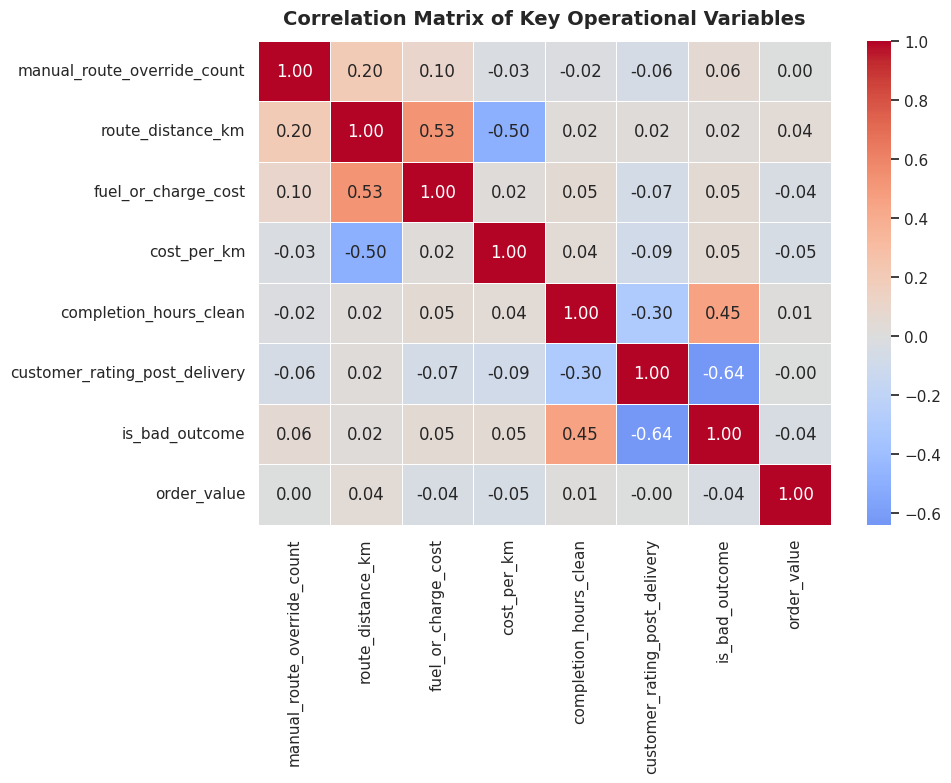

Correlations with is_bad_outcome (ranked by absolute value):
customer_rating_post_delivery   0.640
completion_hours_clean          0.450
manual_route_override_count     0.060
cost_per_km                     0.050
fuel_or_charge_cost             0.050
order_value                     0.040
route_distance_km               0.020
Name: is_bad_outcome, dtype: float64

Interpretation: The correlation matrix shows pairwise relationships between key operational variables. A negative relationship between customer_rating_post_delivery and is_bad_outcome confirms that failed or delayed services receive lower customer ratings. Positive relationships between completion_hours_clean and is_bad_outcome suggest that longer service times are associated with worse delivery outcomes.


In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.4,
    ax=ax
)
ax.set_title('Correlation Matrix of Key Operational Variables', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'python_figure_01_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Highlight the strongest relationships with bad outcome
if 'is_bad_outcome' in corr_matrix.columns:
    corr_bad = corr_matrix['is_bad_outcome'].drop('is_bad_outcome').abs().sort_values(ascending=False)
    print('Correlations with is_bad_outcome (ranked by absolute value):')
    print(corr_bad.round(2))

print('\nInterpretation: The correlation matrix shows pairwise relationships between key '
      'operational variables. A negative relationship between customer_rating_post_delivery '
      'and is_bad_outcome confirms that failed or delayed services receive lower customer ratings. '
      'Positive relationships between completion_hours_clean and is_bad_outcome suggest that '
      'longer service times are associated with worse delivery outcomes.')

---
## **Pairwise Numerical Feature Plot**

The rubric and the old workflow reference both specifically ask for pairwise plots across numerical features. This Seaborn pairplot shows every combination of selected numerical delivery variables, coloured by delivery status. It supports broad exploratory analysis.

Rows used in pairplot: 800


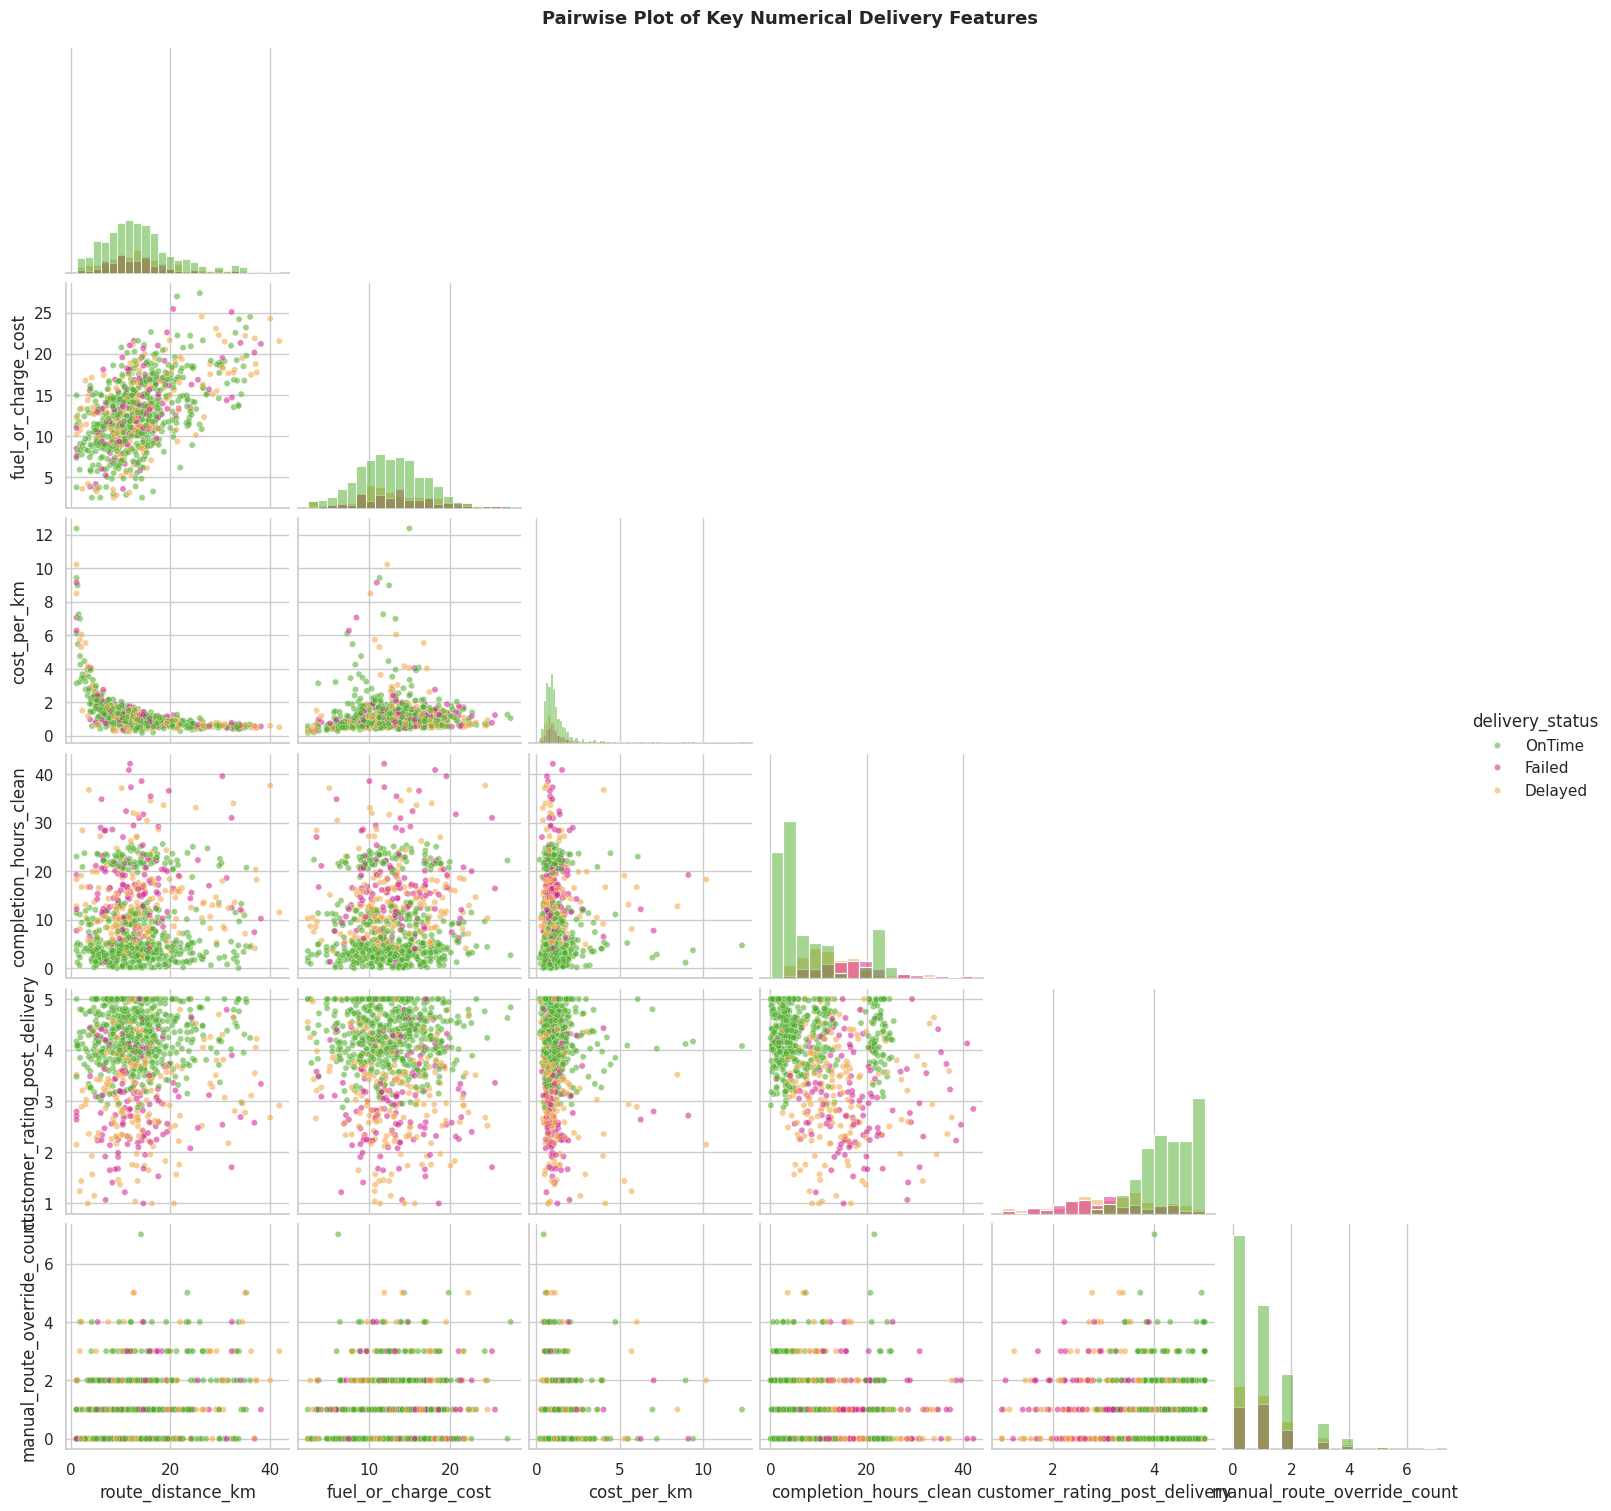


Interpretation: The pairwise plot shows the distribution of each variable on the diagonal, and scatter plots for every variable combination off the diagonal. Points are colour-coded by delivery status. Clusters or separation between colours in the scatter panels reveal where on-time, delayed, and failed deliveries differ.


In [13]:
pair_cols = [
    'route_distance_km', 'fuel_or_charge_cost', 'cost_per_km',
    'completion_hours_clean', 'customer_rating_post_delivery',
    'manual_route_override_count', 'delivery_status'
]
pair_cols = [c for c in pair_cols if c in ops_df.columns]
pair_data = ops_df[pair_cols].dropna()

# Sample to keep the plot readable and fast (800 rows max)
if len(pair_data) > 800:
    pair_data = pair_data.sample(800, random_state=42)

print(f'Rows used in pairplot: {len(pair_data)}')

pair_grid = sns.pairplot(
    pair_data,
    hue='delivery_status',
    palette={'OnTime': '#4dac26', 'Delayed': '#f1a340', 'Failed': '#d01c8b'},
    diag_kind='hist',
    plot_kws={'alpha': 0.55, 's': 20},
    corner=True
)
pair_grid.figure.suptitle(
    'Pairwise Plot of Key Numerical Delivery Features',
    y=1.01, fontsize=13, fontweight='bold'
)
pair_grid.savefig(
    OUTPUT_PATH / 'python_figure_02_pairwise_numerical_features.png',
    dpi=200, bbox_inches='tight'
)
plt.show()
plt.close('all')   # important in Colab to free memory after pairplot

print('\nInterpretation: The pairwise plot shows the distribution of each variable on the diagonal, '
      'and scatter plots for every variable combination off the diagonal. Points are colour-coded '
      'by delivery status. Clusters or separation between colours in the scatter panels reveal '
      'where on-time, delayed, and failed deliveries differ.')

---
## **Scatter Plot - Route Distance and Fuel or Charge Cost**

This scatter plot tests whether longer routes are linked to higher fuel or charge costs. A positive trend would support the finance director's concern about route-based cost differences across zones and service types.

Pearson r (distance vs fuel cost): 0.524


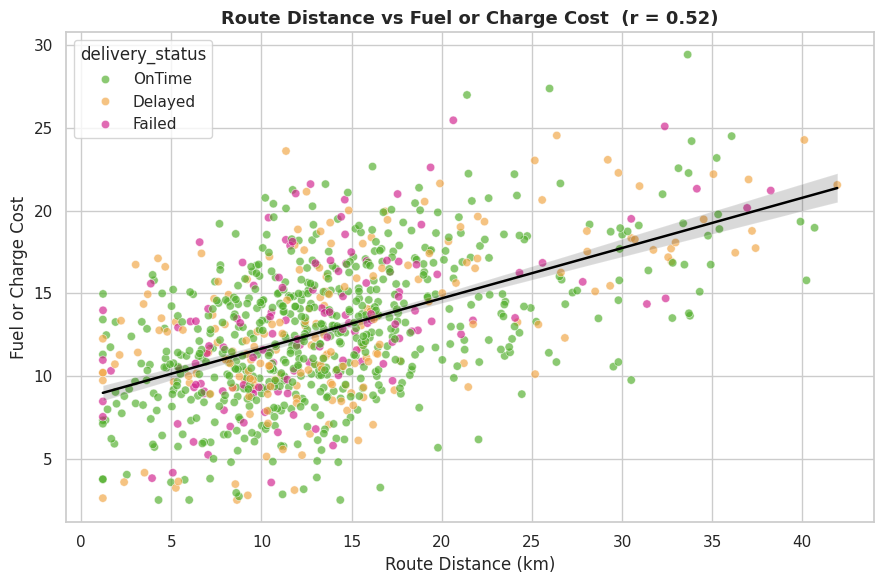


Interpretation: A positive correlation between route distance and fuel cost is expected because longer routes consume more energy. The colour coding by delivery status shows whether delayed or failed deliveries cluster at particular distance ranges.


In [14]:
scatter1 = ops_df[['route_distance_km', 'fuel_or_charge_cost', 'delivery_status']].dropna()

# Use NumPy to compute the correlation coefficient explicitly
r_dist_cost = np.corrcoef(
    scatter1['route_distance_km'].to_numpy(),
    scatter1['fuel_or_charge_cost'].to_numpy()
)[0, 1]
print(f'Pearson r (distance vs fuel cost): {r_dist_cost:.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=scatter1, x='route_distance_km', y='fuel_or_charge_cost',
    hue='delivery_status',
    palette={'OnTime': '#4dac26', 'Delayed': '#f1a340', 'Failed': '#d01c8b'},
    alpha=0.65, ax=ax
)
sns.regplot(
    data=scatter1, x='route_distance_km', y='fuel_or_charge_cost',
    scatter=False, color='black', line_kws={'linewidth': 1.8}, ax=ax
)
ax.set_title(
    f'Route Distance vs Fuel or Charge Cost  (r = {r_dist_cost:.2f})',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Route Distance (km)')
ax.set_ylabel('Fuel or Charge Cost')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'python_figure_03_distance_cost_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('\nInterpretation: A positive correlation between route distance and fuel cost is expected '
      'because longer routes consume more energy. The colour coding by delivery status shows '
      'whether delayed or failed deliveries cluster at particular distance ranges.')

---
## **Scatter Plot - Completion Time and Customer Rating**

This chart tests whether longer completion times are linked to lower customer ratings. This is one of the most direct connections between operational delays and customer dissatisfaction in the NorthStar case study.

Pearson r (completion hours vs rating): -0.252


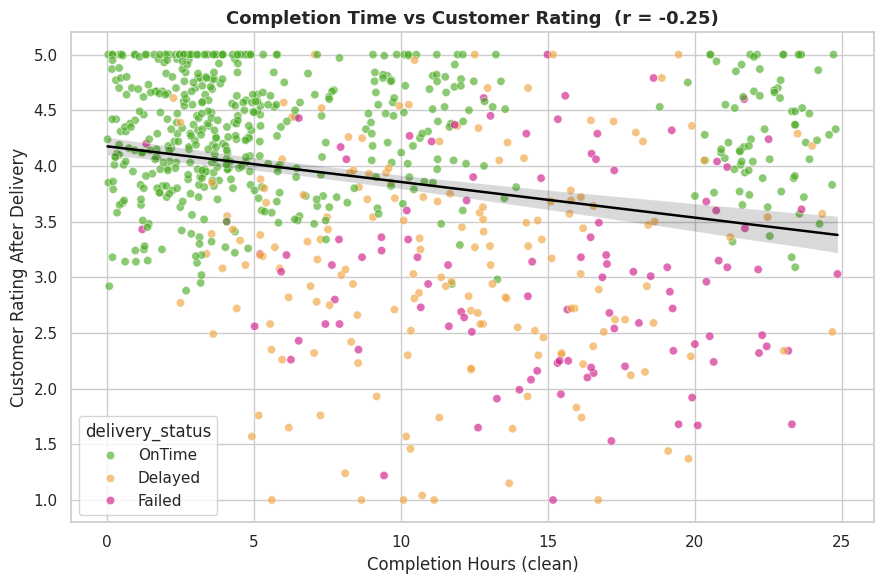


Interpretation: A negative relationship here would confirm that as service delivery takes longer, customers give lower ratings. This is important evidence for both the operations director and the customer experience director in the case study.


In [15]:
scatter2 = ops_df[['completion_hours_clean', 'customer_rating_post_delivery',
                    'delivery_status']].dropna()

# Cap extreme completion values at 95th percentile for a cleaner chart
cap = scatter2['completion_hours_clean'].quantile(0.95)
scatter2 = scatter2[scatter2['completion_hours_clean'] <= cap]

r_time_rating = np.corrcoef(
    scatter2['completion_hours_clean'].to_numpy(),
    scatter2['customer_rating_post_delivery'].to_numpy()
)[0, 1]
print(f'Pearson r (completion hours vs rating): {r_time_rating:.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=scatter2, x='completion_hours_clean', y='customer_rating_post_delivery',
    hue='delivery_status',
    palette={'OnTime': '#4dac26', 'Delayed': '#f1a340', 'Failed': '#d01c8b'},
    alpha=0.65, ax=ax
)
sns.regplot(
    data=scatter2, x='completion_hours_clean', y='customer_rating_post_delivery',
    scatter=False, color='black', line_kws={'linewidth': 1.8}, ax=ax
)
ax.set_title(
    f'Completion Time vs Customer Rating  (r = {r_time_rating:.2f})',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Completion Hours (clean)')
ax.set_ylabel('Customer Rating After Delivery')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'python_figure_04_completion_rating_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('\nInterpretation: A negative relationship here would confirm that as service delivery takes '
      'longer, customers give lower ratings. This is important evidence for both the operations '
      'director and the customer experience director in the case study.')

---
## **Zone Operational Risk Score Using NumPy Normalisation**

This step combines several operational indicators into a single composite risk score for each pickup zone. The four components are bad outcome rate, complaint rate, average cost per km, and inverted average customer rating (so a lower rating contributes a higher risk score). Each component is normalised to a 0-1 scale using NumPy's min-max logic before being combined with fixed weights.

In [16]:
zone_risk = zone_perf.copy()

for col in ['bad_outcome_rate', 'complaint_rate', 'avg_cost_per_km', 'avg_rating']:
    if col in zone_risk.columns:
        zone_risk[col] = pd.to_numeric(zone_risk[col], errors='coerce')

# NumPy min-max normalisation function
def minmax_norm(series):
    arr = series.to_numpy(dtype=float)
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mx == mn:
        return pd.Series(np.zeros(len(arr)), index=series.index)
    return pd.Series((arr - mn) / (mx - mn), index=series.index)

zone_risk['bad_outcome_norm'] = minmax_norm(zone_risk['bad_outcome_rate'])
zone_risk['complaint_norm']   = minmax_norm(zone_risk['complaint_rate'])
zone_risk['cost_norm']        = minmax_norm(zone_risk['avg_cost_per_km'])
zone_risk['low_rating_norm']  = 1 - minmax_norm(zone_risk['avg_rating'])

# Weighted combination (weights sum to 1.0)
zone_risk['risk_score'] = (
    0.40 * zone_risk['bad_outcome_norm'] +
    0.25 * zone_risk['complaint_norm']   +
    0.20 * zone_risk['cost_norm']        +
    0.15 * zone_risk['low_rating_norm']
).round(3)

zone_risk = zone_risk.sort_values('risk_score', ascending=False)

display(zone_risk[['pickup_zone_clean', 'bad_outcome_rate', 'complaint_rate',
                    'avg_cost_per_km', 'avg_rating', 'risk_score']].round(3))

,pickup_zone_clean,bad_outcome_rate,complaint_rate,avg_cost_per_km,avg_rating,risk_score
0,Central,0.483,0.235,1.324,3.546,0.868
2,Riverside,0.361,0.258,1.418,3.864,0.628
4,North,0.319,0.287,1.338,3.897,0.583
3,East,0.321,0.222,1.359,3.912,0.451
6,South,0.259,0.221,1.402,4.052,0.307
1,Airport,0.381,0.194,0.616,3.984,0.293
5,West,0.307,0.168,1.248,3.896,0.290


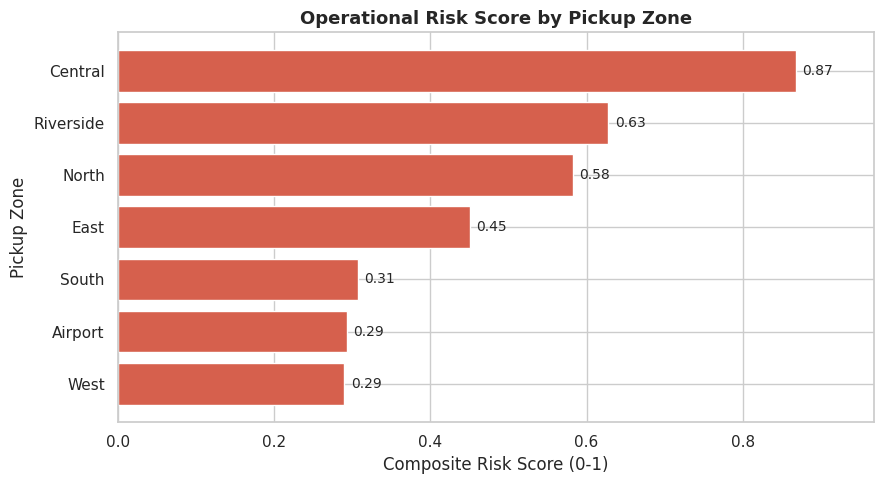


Interpretation: The composite risk score ranks zones by combining bad outcome rate, complaint rate, average cost, and customer rating into one number. This is more informative than looking at a single indicator because a zone might rank moderately on every individual measure but still have a high combined risk. The highest-risk zones should be the first priority for NorthStar operational review.


In [17]:
plot_z = zone_risk.sort_values('risk_score', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot_z['pickup_zone_clean'], plot_z['risk_score'], color='#d6604d')
for bar, val in zip(bars, plot_z['risk_score']):
    ax.text(val + 0.008, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)
ax.set_xlim(0, plot_z['risk_score'].max() + 0.10)
ax.set_title('Operational Risk Score by Pickup Zone', fontsize=13, fontweight='bold')
ax.set_xlabel('Composite Risk Score (0-1)')
ax.set_ylabel('Pickup Zone')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'python_figure_05_zone_risk_score.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('\nInterpretation: The composite risk score ranks zones by combining bad outcome rate, '
      'complaint rate, average cost, and customer rating into one number. This is more informative '
      'than looking at a single indicator because a zone might rank moderately on every individual '
      'measure but still have a high combined risk. The highest-risk zones should be the first '
      'priority for NorthStar operational review.')

---
## **Service Type Performance Analysis**

This section compares NorthStar service types on bad outcome rate and complaint rate. The results help identify whether certain service lines carry more operational or reputational risk.

In [18]:
service_summary = (
    ops_df.groupby('service_type')
    .agg(
        total_orders       = ('order_id',                    'count'),
        delivery_records   = ('delivery_id',                 lambda x: x.notna().sum()),
        bad_outcomes       = ('is_bad_outcome',              'sum'),
        complaints         = ('has_complaint',               'sum'),
        avg_rating         = ('customer_rating_post_delivery','mean'),
        avg_cost_per_km    = ('cost_per_km',                 'mean'),
        avg_completion_hrs = ('completion_hours_clean',      'mean')
    )
    .reset_index()
)

service_summary['bad_outcome_rate'] = np.where(
    service_summary['delivery_records'] > 0,
    service_summary['bad_outcomes'] / service_summary['delivery_records'],
    np.nan
)
service_summary['complaint_rate'] = (
    service_summary['complaints'] / service_summary['total_orders']
)
service_summary = service_summary.sort_values('bad_outcome_rate', ascending=False)

display(service_summary.round(3))

,service_type,total_orders,delivery_records,bad_outcomes,complaints,avg_rating,avg_cost_per_km,avg_completion_hrs,bad_outcome_rate,complaint_rate
0,Business,165,126,53.000,34,3.847,1.235,10.051,0.421,0.206
1,Medical,139,108,38.000,33,3.838,1.408,11.011,0.352,0.237
4,Retail,297,224,78.000,72,3.873,1.231,10.216,0.348,0.242
3,Passenger,341,262,91.000,77,3.845,1.212,9.976,0.347,0.226
2,Parcel,308,230,74.000,69,3.902,1.293,10.634,0.322,0.224


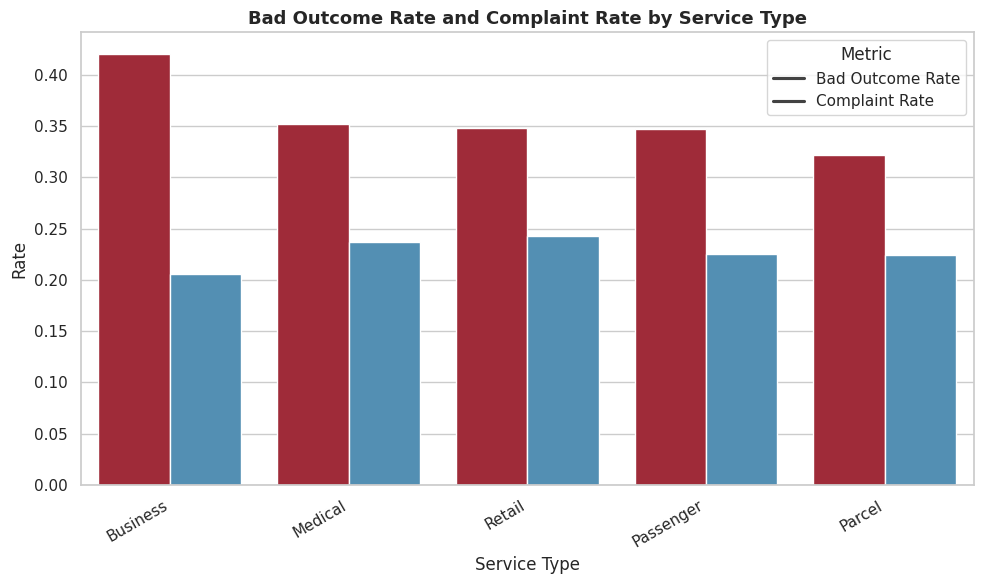


Interpretation: Service types with high bad outcome rates and high complaint rates need operational attention. Where a service type has a high complaint rate but a lower bad outcome rate, the issue may be less about delivery failures and more about customer communication or service expectations.


In [19]:
service_long = service_summary.melt(
    id_vars='service_type',
    value_vars=['bad_outcome_rate', 'complaint_rate'],
    var_name='metric',
    value_name='rate'
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=service_long, x='service_type', y='rate', hue='metric',
    palette={'bad_outcome_rate': '#b2182b', 'complaint_rate': '#4393c3'},
    ax=ax
)
ax.set_title('Bad Outcome Rate and Complaint Rate by Service Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Service Type')
ax.set_ylabel('Rate')
ax.legend(title='Metric', labels=['Bad Outcome Rate', 'Complaint Rate'])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'python_figure_06_service_type_rates.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('\nInterpretation: Service types with high bad outcome rates and high complaint rates need '
      'operational attention. Where a service type has a high complaint rate but a lower bad '
      'outcome rate, the issue may be less about delivery failures and more about customer '
      'communication or service expectations.')

---
## **Outlier Detection Using Interquartile Range**

Outlier detection uses the IQR method to identify records where cost per km or completion time is unusually high compared to the rest of the dataset. This is useful for separating genuinely extreme operational cases from the typical distribution.

In [20]:
def flag_iqr_outliers(df, col):
    """Flag rows where the value in col is an IQR outlier (below or above 1.5 * IQR from Q1/Q3)."""
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flags = ((df[col] < lower) | (df[col] > upper)).astype(int)
    return flags, lower, upper

outlier_df = ops_df.copy()

for col in ['cost_per_km', 'completion_hours_clean']:
    if col in outlier_df.columns:
        flag, lo, hi = flag_iqr_outliers(outlier_df.dropna(subset=[col]), col)
        # Reindex so we can assign back to outlier_df
        outlier_df[f'{col}_outlier'] = flag.reindex(outlier_df.index, fill_value=0)
        print(f'{col}: lower limit = {lo:.2f}, upper limit = {hi:.2f}, '
              f'outliers = {flag.sum()} ({100*flag.mean():.1f}%)')

# Summary of outliers by delivery status
outlier_summary = (
    outlier_df.dropna(subset=['delivery_status'])
    .groupby('delivery_status')
    .agg(
        records               = ('order_id', 'count'),
        cost_outliers         = ('cost_per_km_outlier', 'sum'),
        completion_outliers   = ('completion_hours_clean_outlier', 'sum')
    )
    .reset_index()
)
display(outlier_summary)

cost_per_km: lower limit = -0.24, upper limit = 2.27, outliers = 69 (7.3%)
completion_hours_clean: lower limit = -14.54, upper limit = 33.57, outliers = 16 (1.8%)


,delivery_status,records,cost_outliers,completion_outliers
0,Delayed,202,18,7
1,Failed,132,8,9
2,OnTime,616,43,0


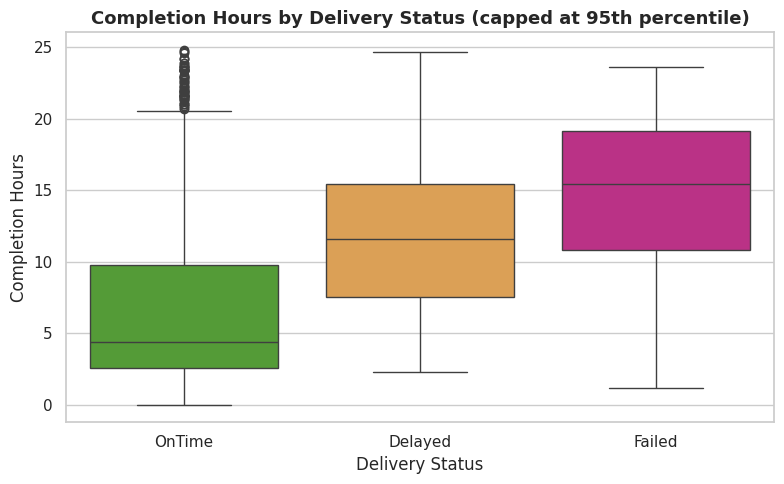


Interpretation: The boxplot shows the typical range of completion hours for each delivery status. The outlier count table above confirms that Failed deliveries have more cost and completion time outliers than on-time ones. These extreme cases warrant investigation because they may represent particularly problematic routes, vehicles, or drivers.


In [21]:
# Boxplot of completion hours by delivery status (capped at 95th percentile for readability)
cap_val = ops_df['completion_hours_clean'].quantile(0.95)
plot_box = ops_df[ops_df['completion_hours_clean'] <= cap_val].dropna(
    subset=['delivery_status', 'completion_hours_clean']
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=plot_box, x='delivery_status', y='completion_hours_clean',
    palette={'OnTime': '#4dac26', 'Delayed': '#f1a340', 'Failed': '#d01c8b'},
    ax=ax
)
ax.set_title('Completion Hours by Delivery Status (capped at 95th percentile)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Delivery Status')
ax.set_ylabel('Completion Hours')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'python_figure_07_completion_hours_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('\nInterpretation: The boxplot shows the typical range of completion hours for each delivery '
      'status. The outlier count table above confirms that Failed deliveries have more cost and '
      'completion time outliers than on-time ones. These extreme cases warrant investigation because '
      'they may represent particularly problematic routes, vehicles, or drivers.')

---
## **App Event Performance Analysis**

NorthStar's mobile platform is central to the case study. This section uses Pandas to summarise API latency and success rates by event type and device type. High latency for important event types can directly affect customer satisfaction.

In [22]:
app_summary = (
    app_events.groupby('event_type')
    .agg(
        event_count       = ('event_id',      'count'),
        avg_latency_ms    = ('api_latency_ms', 'mean'),
        median_latency_ms = ('api_latency_ms', 'median'),
        success_rate_pct  = ('success_flag',   lambda x: round(x.mean() * 100, 1))
    )
    .reset_index()
    .sort_values('avg_latency_ms', ascending=False)
    .round(2)
)
display(app_summary)

device_summary = (
    app_events.groupby('device_type')
    .agg(
        event_count      = ('event_id',      'count'),
        avg_latency_ms   = ('api_latency_ms', 'mean'),
        success_rate_pct = ('success_flag',   lambda x: round(x.mean() * 100, 1))
    )
    .reset_index()
    .round(2)
)
print('\nLatency and success rate by device type:')
display(device_summary)

,event_type,event_count,avg_latency_ms,median_latency_ms,success_rate_pct
3,delivery_instruction_update,75,496.290,446.000,100.000
2,chat_opened,88,478.330,416.500,100.000
1,chat_escalated,38,478.130,411.000,50.000
5,payment_retry,69,472.680,440.000,72.500
7,track_order,138,460.710,427.000,100.000
6,search_route,99,456.510,457.000,100.000
4,eta_refresh,105,452.150,440.000,100.000
0,cancel_attempt,28,417.140,414.000,100.000



Latency and success rate by device type:


,device_type,event_count,avg_latency_ms,success_rate_pct
0,Android,315,464.900,93.300
1,Web,92,474.680,93.500
2,iOS,233,463.150,95.300


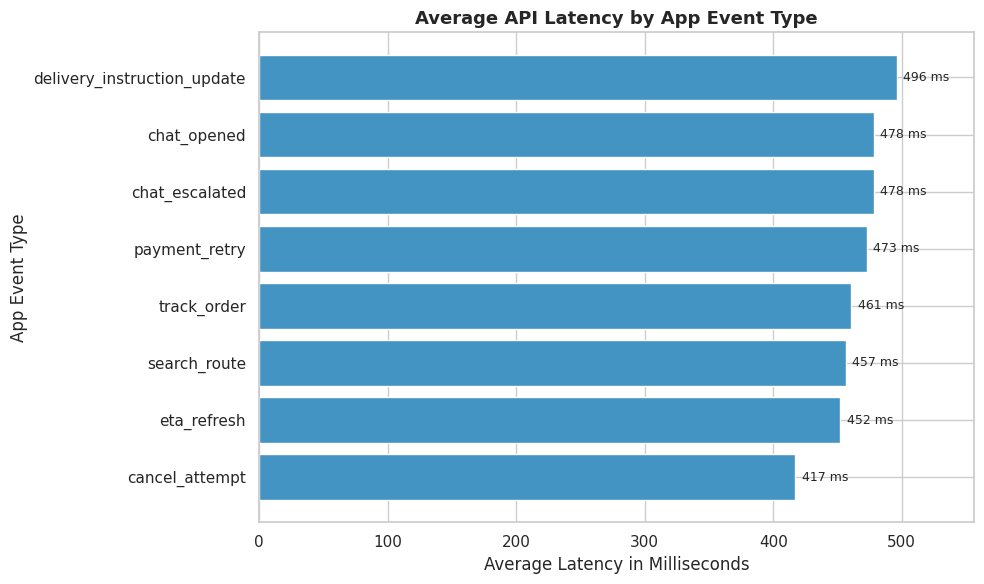


Interpretation: Event types with high average latency are likely responsible for the AppIssue complaints found in earlier analysis. If customer-facing events such as ETA refresh, payment retry, or chat escalation show high latency, this contributes to poor digital service experience and can result in repeated app interactions that generate more event data and further increase system load.


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_app = app_summary.sort_values('avg_latency_ms', ascending=True)
bars = ax.barh(plot_app['event_type'], plot_app['avg_latency_ms'], color='#4393c3')
for bar, val in zip(bars, plot_app['avg_latency_ms']):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} ms', va='center', fontsize=9)
ax.set_xlim(0, plot_app['avg_latency_ms'].max() + 60)
ax.set_title('Average API Latency by App Event Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Latency in Milliseconds')
ax.set_ylabel('App Event Type')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'python_figure_08_app_event_latency.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('\nInterpretation: Event types with high average latency are likely responsible for the '
      'AppIssue complaints found in earlier analysis. If customer-facing events such as ETA refresh, '
      'payment retry, or chat escalation show high latency, this contributes to poor digital service '
      'experience and can result in repeated app interactions that generate more event data and '
      'further increase system load.')

---
## **Automated Insight Summary**

This step collects the most important quantitative findings from the analysis into a single summary table. These findings can be used directly in the report under the Python Analytics section.

In [24]:
insight_rows = []

# Strongest variable correlated with bad outcome
if 'is_bad_outcome' in corr_matrix.columns:
    top_corr = (
        corr_matrix['is_bad_outcome']
        .drop('is_bad_outcome')
        .abs()
        .sort_values(ascending=False)
    )
    insight_rows.append({
        'area':    'Correlation',
        'finding': f'{top_corr.index[0]} has the strongest relationship with bad outcome',
        'value':   round(float(corr_matrix.loc[top_corr.index[0], 'is_bad_outcome']), 2)
    })

# Highest risk zone
top_zone = zone_risk.iloc[0]
insight_rows.append({
    'area':    'Zone risk',
    'finding': f"{top_zone['pickup_zone_clean']} has the highest composite operational risk score",
    'value':   round(float(top_zone['risk_score']), 3)
})

# Highest bad outcome service type
top_service = service_summary.iloc[0]
insight_rows.append({
    'area':    'Service type',
    'finding': f"{top_service['service_type']} has the highest bad outcome rate",
    'value':   round(float(top_service['bad_outcome_rate']), 3)
})

# Highest latency app event
top_event = app_summary.iloc[0]
insight_rows.append({
    'area':    'App events',
    'finding': f"{top_event['event_type']} has the highest average API latency",
    'value':   round(float(top_event['avg_latency_ms']), 1)
})

# Percentage of orders without delivery records
no_delivery_pct = round(100 * ops_df['delivery_id'].isna().sum() / len(ops_df), 1)
insight_rows.append({
    'area':    'Data completeness',
    'finding': 'Percentage of orders with no delivery record',
    'value':   no_delivery_pct
})

insight_summary = pd.DataFrame(insight_rows)
display(insight_summary)

,area,finding,value
0,Correlation,customer_rating_post_delivery has the stronges...,-0.640
1,Zone risk,Central has the highest composite operational ...,0.868
2,Service type,Business has the highest bad outcome rate,0.421
3,App events,delivery_instruction_update has the highest av...,496.300
4,Data completeness,Percentage of orders with no delivery record,24.000


---
## **Save Python Output Tables and Create Output Archive**

All summary tables are saved locally in the Colab session. The output folder is zipped as coursework evidence under `Outputs/Python_Outputs`.

In [25]:
# Save all summary tables
overall_stats.to_csv(OUTPUT_PATH / 'python_overall_descriptive_stats.csv')
numpy_df.to_csv(OUTPUT_PATH / 'python_numpy_summary.csv', index=False)
grouped_stats.to_csv(OUTPUT_PATH / 'python_grouped_by_status_stats.csv', index=False)
corr_matrix.to_csv(OUTPUT_PATH / 'python_correlation_matrix.csv')
zone_risk.to_csv(OUTPUT_PATH / 'python_zone_risk_summary.csv', index=False)
service_summary.to_csv(OUTPUT_PATH / 'python_service_type_summary.csv', index=False)
outlier_summary.to_csv(OUTPUT_PATH / 'python_outlier_summary.csv', index=False)
app_summary.to_csv(OUTPUT_PATH / 'python_app_event_summary.csv', index=False)
device_summary.to_csv(OUTPUT_PATH / 'python_device_summary.csv', index=False)
insight_summary.to_csv(OUTPUT_PATH / 'python_insight_summary.csv', index=False)

print(f'All Python output tables saved locally in Colab: {OUTPUT_PATH}')
print('\nSaved files:')
for f in sorted(OUTPUT_PATH.glob('*')):
    print(f'  {f.name}')

# Create a zip file to archive the output evidence
zip_file_base = '/content/northstar_python_outputs'
zip_file = zip_file_base + '.zip'

if Path(zip_file).exists():
    Path(zip_file).unlink()

zip_file = shutil.make_archive(zip_file_base, 'zip', OUTPUT_PATH)

print('\nPython output zip created:')
print(zip_file)


All Python output tables saved locally in Colab: /content/northstar_python_outputs

Saved files:
  python_app_event_summary.csv
  python_correlation_matrix.csv
  python_device_summary.csv
  python_figure_01_correlation_heatmap.png
  python_figure_02_pairwise_numerical_features.png
  python_figure_03_distance_cost_scatter.png
  python_figure_04_completion_rating_scatter.png
  python_figure_05_zone_risk_score.png
  python_figure_06_service_type_rates.png
  python_figure_07_completion_hours_boxplot.png
  python_figure_08_app_event_latency.png
  python_grouped_by_status_stats.csv
  python_insight_summary.csv
  python_numpy_summary.csv
  python_outlier_summary.csv
  python_overall_descriptive_stats.csv
  python_service_type_summary.csv
  python_zone_risk_summary.csv

Python output zip created:
/content/northstar_python_outputs.zip


## **Summary of Python Pandas and NumPy Analytics**

The cleaned NorthStar data was analysed using Pandas and NumPy to generate descriptive statistics, correlation results, pairwise numerical plots, scatter plots, risk scores, service type comparisons, timing analysis, app event summaries, and outlier evidence. These results support the Python analytics section of the final coursework report.